#  <h1 align="center">Descriptive Analysis</h1>

## 1 . Glucose Level Distribution: How much time do patients spend in Hypoglycemia, Normal, and Hyperglycemia zones?

#### Why I chose this Biomarker: Glucose is the core clinical variable in a diabetes dataset. It directly measures how well blood sugar is being controlled.
#### Why it's important to the medical condition: T1DM patients must maintain glucose between 70–180 mg/dL. Time spent outside this range especially in hypoglycemia (<70) which is dangerous and life-threatening. This analysis reveals which patients have the poorest glucose control.

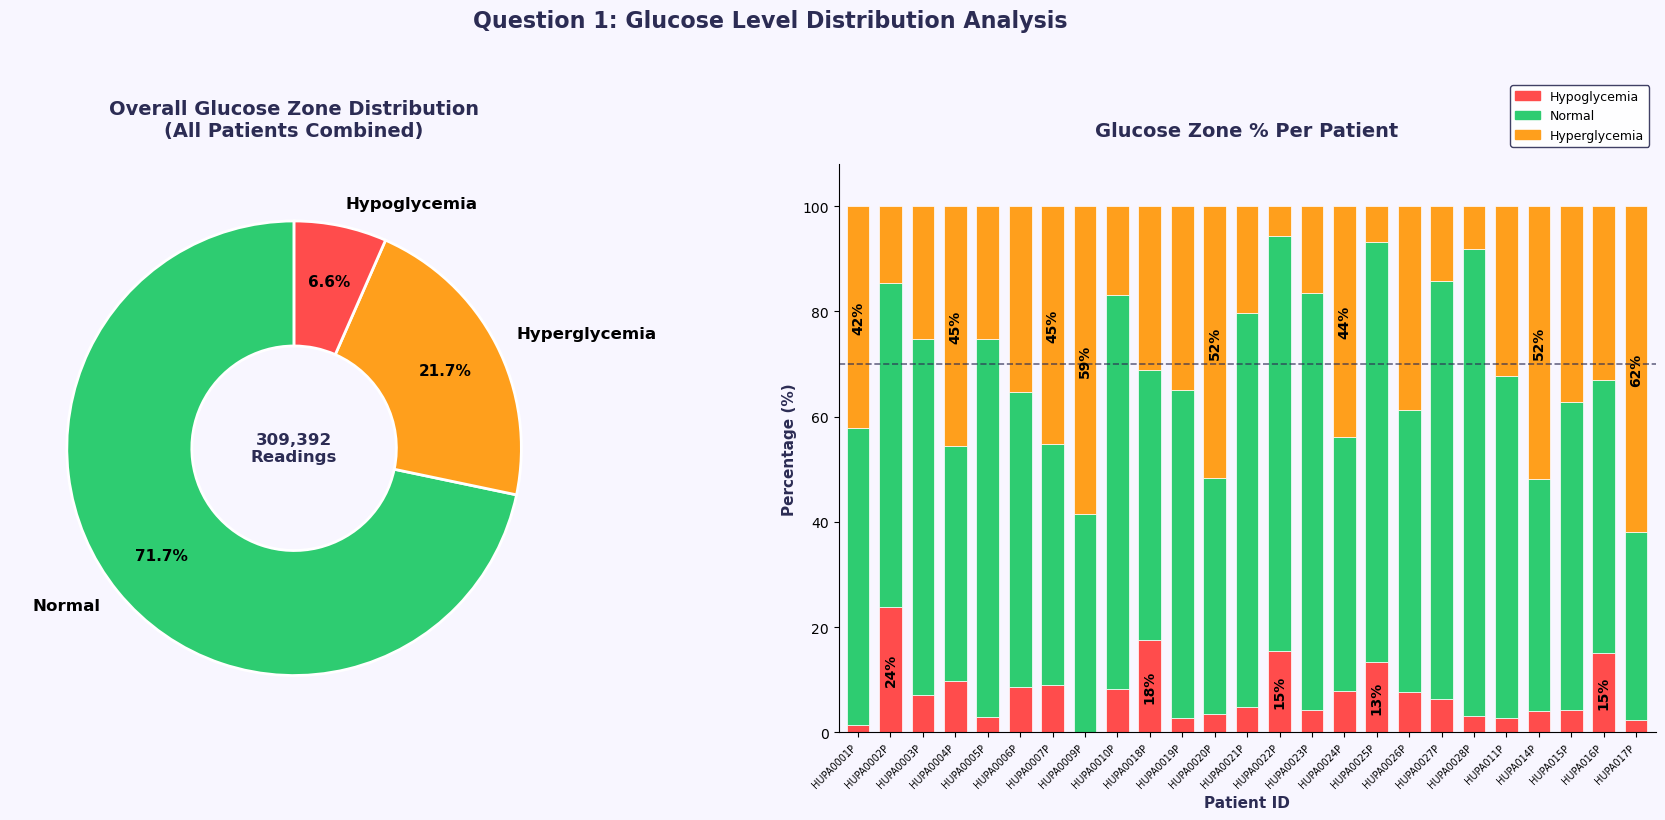

Chart saved successfully!

=== Overall Glucose Zone Distribution ===
  Normal         : 71.7%
  Hyperglycemia  : 21.7%
  Hypoglycemia   : 6.6%

Most at-risk patient : HUPA0002P (23.86% hypoglycemia)
Best controlled      : HUPA0028P (88.79% normal range)


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv"
)

# ── Classify Glucose Zones ────────────────────────────────────────────────────
def classify_glucose(g):
    if g < 70:
        return 'Hypoglycemia'
    elif g <= 180:
        return 'Normal'
    else:
        return 'Hyperglycemia'

df['Glucose_Zone'] = df['Glucose'].apply(classify_glucose)

# ── Zone Colors ───────────────────────────────────────────────────────────────
zone_colors = {
    'Hypoglycemia'  : '#FF4C4C',
    'Normal'        : '#2ECC71',
    'Hyperglycemia' : '#FF9F1C'
}

# ── Overall Distribution ──────────────────────────────────────────────────────
zone_counts = df['Glucose_Zone'].value_counts()
zone_pct    = (zone_counts / len(df) * 100).round(2)

# ── Per Patient Breakdown ─────────────────────────────────────────────────────
patient_zone = (
    df.groupby(['Patient_Id', 'Glucose_Zone'])
    .size()
    .unstack(fill_value=0)
)
patient_zone_pct = (
    patient_zone.div(patient_zone.sum(axis=1), axis=0) * 100
).round(2)

for col in ['Hypoglycemia', 'Normal', 'Hyperglycemia']:
    if col not in patient_zone_pct.columns:
        patient_zone_pct[col] = 0
patient_zone_pct = patient_zone_pct[['Hypoglycemia', 'Normal', 'Hyperglycemia']]

# ── FIGURE ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('#F8F6FF')

# ── Donut Chart ───────────────────────────────────────────────────────────────
wedge_colors = [zone_colors[z] for z in zone_pct.index]
wedges, texts, autotexts = axes[0].pie(
    zone_pct.values,
    labels=zone_pct.index,
    autopct='%1.1f%%',
    colors=wedge_colors,
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=2)
)
for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
    autotext.set_color('black')

axes[0].set_title('Overall Glucose Zone Distribution\n(All Patients Combined)',
                  fontsize=14, fontweight='bold', pad=20, color='#2C2C54')
axes[0].set_facecolor('#F8F6FF')
axes[0].text(0, 0, f'{len(df):,}\nReadings',
             ha='center', va='center',
             fontsize=12, fontweight='bold', color='#2C2C54')

# ── Stacked Bar Chart ─────────────────────────────────────────────────────────
bar_colors = [zone_colors[z] for z in ['Hypoglycemia', 'Normal', 'Hyperglycemia']]
patient_zone_pct.plot(
    kind='bar',
    stacked=True,
    color=bar_colors,
    ax=axes[1],
    edgecolor='white',
    linewidth=0.5,
    width=0.7,
    legend=False
)

# ── Add % Labels for High Risk Patients ───────────────────────────────────────
for i, patient in enumerate(patient_zone_pct.index):
    hypo_pct  = patient_zone_pct.loc[patient, 'Hypoglycemia']
    hyper_pct = patient_zone_pct.loc[patient, 'Hyperglycemia']

    # Hypoglycemia label — inside the red bar, rotated vertical
    if hypo_pct > 10:
        axes[1].text(
            i, hypo_pct / 2,
            f'{hypo_pct:.0f}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='black',
            rotation=90
        )

    # Hyperglycemia label — inside the orange bar, rotated vertical
    if hyper_pct > 40:
        normal_pct = patient_zone_pct.loc[patient, 'Normal']
        axes[1].text(
            i, hypo_pct + normal_pct + hyper_pct / 2,
            f'{hyper_pct:.0f}%',
            ha='center', va='center',
            fontsize=10, fontweight='bold',
            color='black',
            rotation=90
        )

axes[1].set_title('Glucose Zone % Per Patient',
                  fontsize=14, fontweight='bold', pad=20, color='#2C2C54')
axes[1].set_xlabel('Patient ID', fontsize=11, fontweight='bold', color='#2C2C54')
axes[1].set_ylabel('Percentage (%)', fontsize=11, fontweight='bold', color='#2C2C54')
axes[1].tick_params(axis='x', labelsize=7)
axes[1].set_xticklabels(patient_zone_pct.index, rotation=45, ha='right')
axes[1].set_facecolor('#F8F6FF')
axes[1].set_ylim(0, 108)              # ← increased to give space for labels above bars
axes[1].axhline(y=70, color='#2C2C54', linestyle='--', linewidth=1.2, alpha=0.7)
axes[1].spines[['top', 'right']].set_visible(False)

# ── Legend — Top Right Corner Outside Chart ───────────────────────────────────
patches = [mpatches.Patch(color=zone_colors[z], label=z)
           for z in ['Hypoglycemia', 'Normal', 'Hyperglycemia']]
axes[1].legend(
    handles=patches,
    loc='upper right',
    bbox_to_anchor=(1.0, 1.15),
    ncol=1,
    fontsize=9,
    framealpha=0.9,
    edgecolor='#2C2C54'
)

plt.suptitle('Question 1: Glucose Level Distribution Analysis',
             fontsize=16, fontweight='bold', color='#2C2C54', y=1.02)
plt.tight_layout()
plt.savefig(
    r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Q1_Glucose_Distribution.png",
    dpi=150, bbox_inches='tight', facecolor='#F8F6FF'
)
plt.show()
print("Chart saved successfully!")

# ── Summary Stats ─────────────────────────────────────────────────────────────
print("\n=== Overall Glucose Zone Distribution ===")
for zone, pct in zone_pct.items():
    print(f"  {zone:15}: {round(pct, 1)}%")
    
most_at_risk = patient_zone_pct['Hypoglycemia'].idxmax()
print(f"\nMost at-risk patient : {most_at_risk} "
      f"({patient_zone_pct.loc[most_at_risk, 'Hypoglycemia']}% hypoglycemia)")
print(f"Best controlled      : {patient_zone_pct['Normal'].idxmax()} "
      f"({patient_zone_pct['Normal'].max()}% normal range)")

#### Insight:
#### In doughnut chart Out of 309,392 total glucose readings across all 25 patients, 71.7% are in the safe normal range. However, 21.7% show high glucose (hyperglycemia) and 6.6% show dangerously low glucose (hypoglycemia) — meaning patients are spending nearly 30% of their time outside the safe zone.
#### In Stacked Bar Chart High Hypoglycemia patients (red labels): HUPA0002P is the most at-risk patient with 24% of readings in the danger low zone  meaning 1 in every 4 readings was a potentially life-threatening low glucose episode. HUPA0018P (18%), HUPA0022P (15%), and HUPA016P (15%) also show alarmingly high hypoglycemia rates that need immediate clinical attention. 
#### High Hyperglycemia patients (orange labels): HUPA017P has the highest hyperglycemia at 62% — spending more than half their recorded time with dangerously high glucose. HUPA0009P (59%), HUPA014P and HUPA0020P (both around 52%) also show persistently elevated glucose levels that silently damage organs over time.
#### Hence This analysis shows that while most patients maintain safe glucose levels most of the time, there are critical outliers on both ends patients dangerously low and dangerously high and these charts instantly tells us exactly who they are.


## 2.What is the distribution of physical activity (steps and calories burned) across patients and how does it vary?

#### Why I Chose Steps and Calories as the Biomarker : Steps and calories are the only columns in this dataset that capture patient physical activity. Choosing both together gives a complete picture steps measure how much the patient moves, calories measure how hard they worked. No other team member has analysed these columns, making this a unique and valuable addition to the overall analysis.

#### Why it's important to the medical condition: Physical activity directly lowers blood sugar in diabetic patients  when they move, muscles absorb glucose naturally without insulin. Analysing steps and calories identifies sedentary patients who are at higher risk of persistent hyperglycemia and need lifestyle intervention alongside medication.

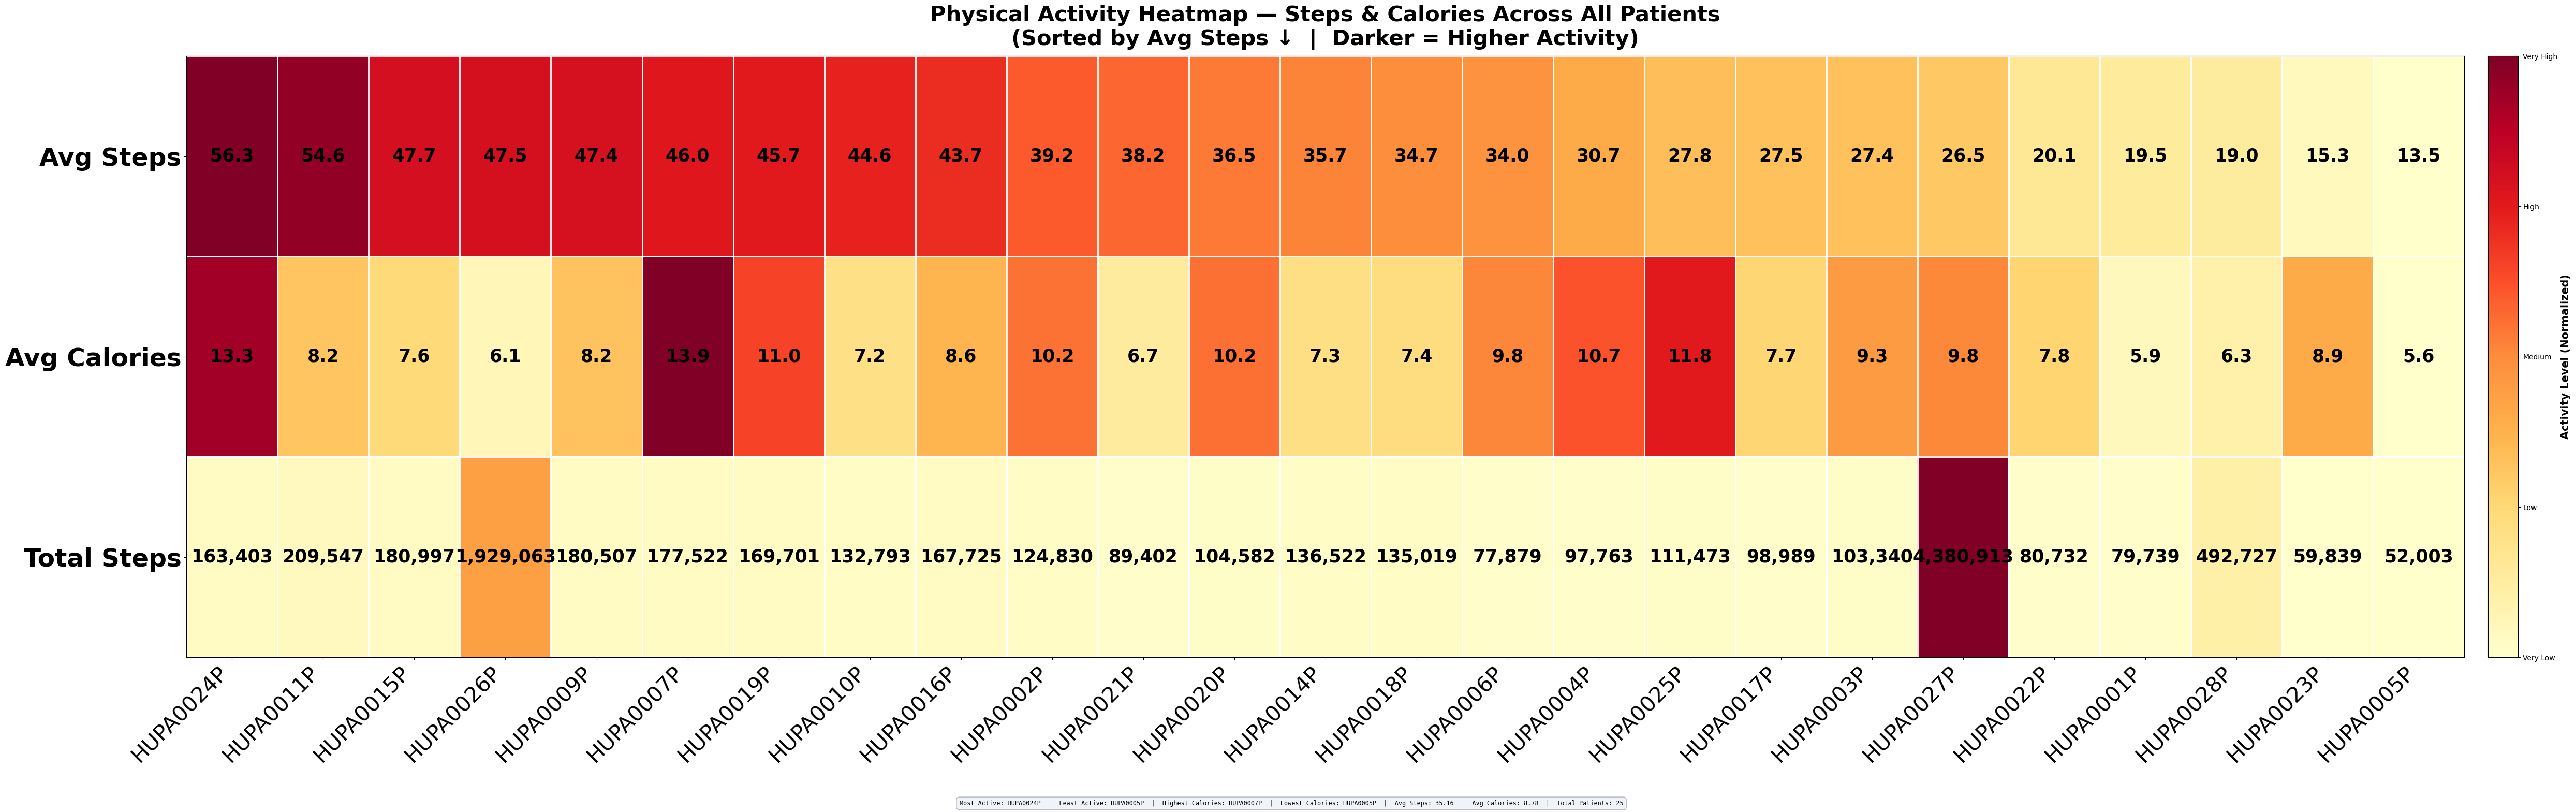

✅ Heatmap saved!


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ── Load ──
df = pd.read_csv(r"C:\Users\vidya\OneDrive\Desktop\DATA ANALYST\NUMPY NINJA\GITHUB\Team2_-PyQueens_-Python-Hackathon-_MAY-2026\Final cleaned csv files\Final cleaned csv files\Team2_PyQueens_Final_Cleaned_File.csv")

# ── Aggregate ──
activity_summary = df.groupby('Patient_Id').agg(
    avg_steps    = ('Steps',    'mean'),
    avg_calories = ('Calories', 'mean'),
    total_steps  = ('Steps',    'sum')
).reset_index().sort_values('avg_steps', ascending=False).reset_index(drop=True)

# ── Build heatmap — Transposed (patients = X, metrics = Y) ──
heatmap_df = activity_summary.set_index('Patient_Id')[['avg_steps','avg_calories','total_steps']]
heatmap_df.columns = ['Avg Steps', 'Avg Calories', 'Total Steps']
heatmap_norm   = (heatmap_df - heatmap_df.min()) / (heatmap_df.max() - heatmap_df.min())
heatmap_T      = heatmap_df.T
heatmap_norm_T = heatmap_norm.T

# ── Plot ──
fig, ax = plt.subplots(figsize=(50, 15))

im = ax.imshow(heatmap_norm_T.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=1)

ax.set_xticks(range(len(heatmap_T.columns)))
ax.set_xticklabels(heatmap_T.columns, fontsize=30, rotation=45, ha='right')
ax.set_yticks(range(len(heatmap_T.index)))
ax.set_yticklabels(heatmap_T.index, fontsize=35, fontweight='bold')

# ── Cell values ──
for row_i in range(len(heatmap_T.index)):
    for col_j in range(len(heatmap_T.columns)):
        raw_val    = heatmap_T.iloc[row_i, col_j]
        norm_val   = heatmap_norm_T.iloc[row_i, col_j]
        label      = f'{int(raw_val):,}' if row_i == 2 else f'{raw_val:.1f}'
        text_color = 'black' if norm_val > 0.6 else 'black'
        ax.text(col_j, row_i, label, ha='center', va='center',
                fontsize=25, fontweight='bold', color=text_color)

# ── Grid ──
ax.set_xticks(np.arange(-0.5, len(heatmap_T.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_T.index),   1), minor=True)
ax.grid(which='minor', color='white', linewidth=2)
ax.tick_params(which='minor', bottom=False, left=False)

# ── Colorbar ──
cbar = plt.colorbar(im, ax=ax, pad=0.01, fraction=0.02)
cbar.set_label('Activity Level (Normalized)', fontsize=15, fontweight='bold')
cbar.set_ticks([0, 0.25, 0.5, 0.75, 1.0])
cbar.set_ticklabels(['Very Low', 'Low', 'Medium', 'High', 'Very High'])

# ── Summary bar below chart ──
most_active  = activity_summary.loc[activity_summary['avg_steps'].idxmax(),    'Patient_Id']
least_active = activity_summary.loc[activity_summary['avg_steps'].idxmin(),    'Patient_Id']
highest_cal  = activity_summary.loc[activity_summary['avg_calories'].idxmax(), 'Patient_Id']
lowest_cal   = activity_summary.loc[activity_summary['avg_calories'].idxmin(), 'Patient_Id']

summary_text = (
    f"Most Active: {most_active}  |  Least Active: {least_active}  |  "
    f"Highest Calories: {highest_cal}  |  Lowest Calories: {lowest_cal}  |  "
    f"Avg Steps: {activity_summary['avg_steps'].mean():.2f}  |  "
    f"Avg Calories: {activity_summary['avg_calories'].mean():.2f}  |  "
    f"Total Patients: {len(activity_summary)}"
)
fig.text(0.5, -0.04, summary_text, ha='center', fontsize=8.5,
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f0f4f8',
                   edgecolor='#aab0bb', alpha=0.95),
         fontfamily='monospace')

ax.set_title(
    'Physical Activity Heatmap — Steps & Calories Across All Patients\n'
    '(Sorted by Avg Steps ↓  |  Darker = Higher Activity)',
    fontsize=30, fontweight='bold', pad=15
)

plt.tight_layout()
plt.savefig('heatmap_horizontal.png', dpi=250, bbox_inches='tight')
plt.show()
print("✅ Heatmap saved!")